In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
xtrain=pd.read_csv('fashion-mnist_train.csv')
xtest=pd.read_csv('fashion-mnist_test.csv')

In [ ]:
# five elements from the top for training data
xtrain.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,2,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# five elements from the top for test data
xtest.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


/tmp/ipykernel_2363/3929875598.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


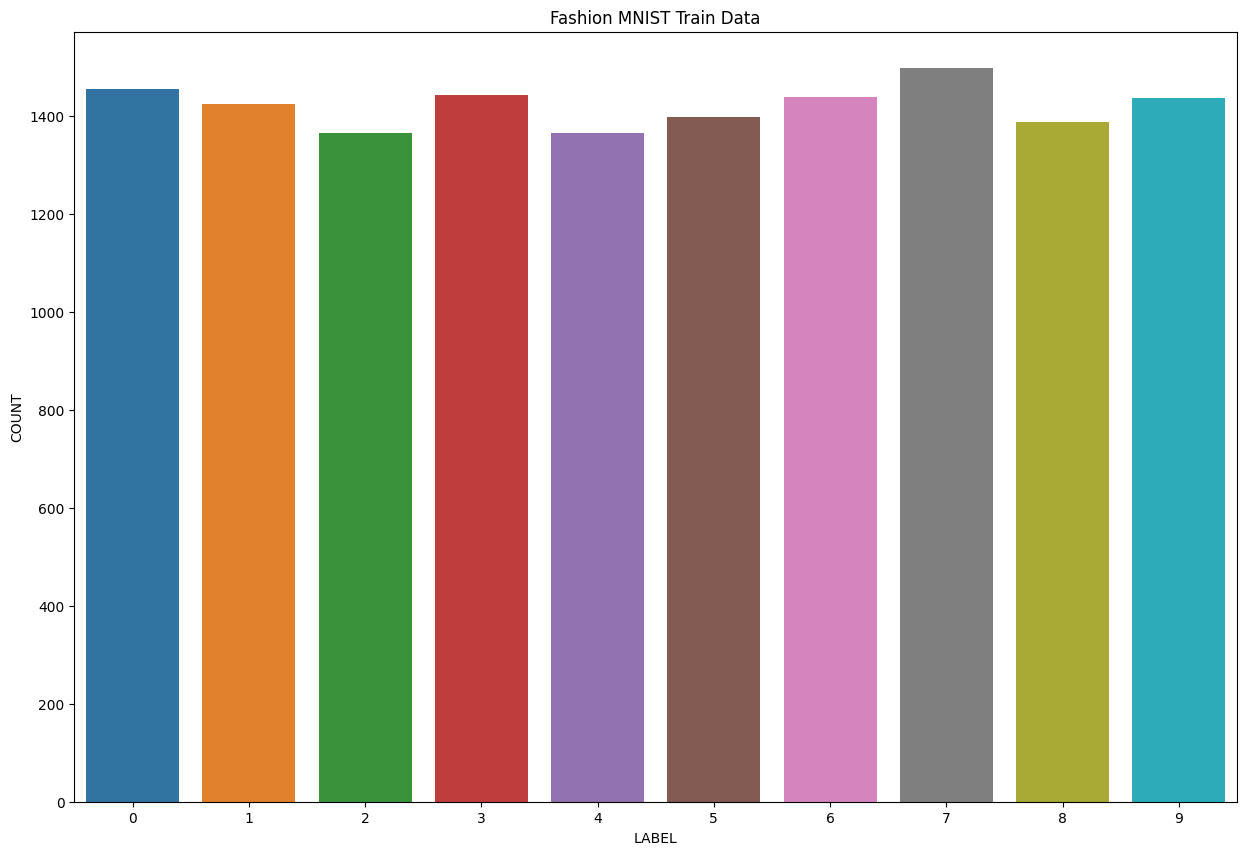

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

sns.countplot(
    x=xtrain['label'],
    palette='tab10'
)

plt.title('Fashion MNIST Train Data')
plt.ylabel('COUNT')
plt.xlabel('LABEL')

plt.show()

/tmp/ipykernel_207/2705143739.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=xtest['label'], palette='tab10')


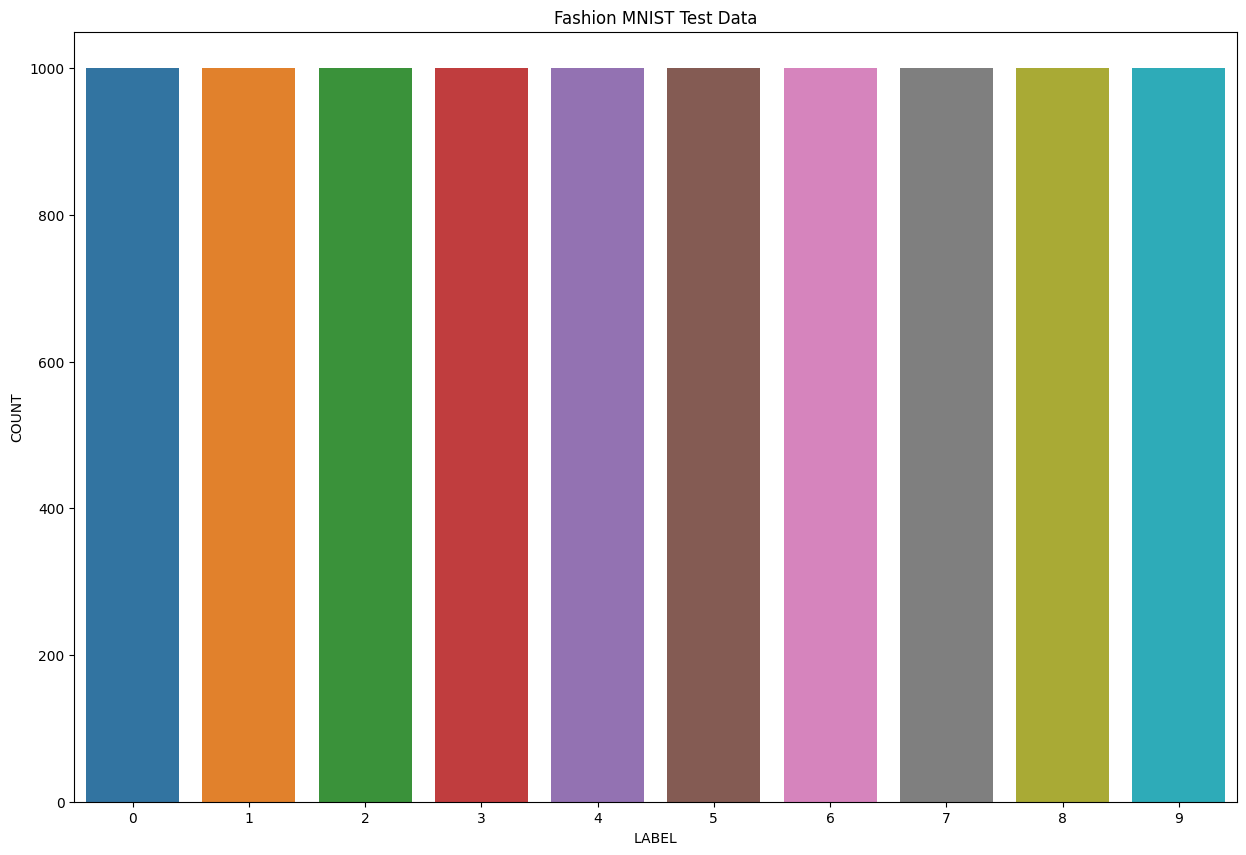

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

sns.countplot(x=xtest['label'], palette='tab10')

plt.title('Fashion MNIST Test Data')
plt.ylabel('COUNT')
plt.xlabel('LABEL')

plt.show()

In [ ]:
ytrain=xtrain['label']
xtrain=xtrain.drop(labels=['label'],axis=1)
ytest=xtest['label']
xtest=xtest.drop(labels=['label'],axis=1)
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)

(14210, 784) (14210,)
(10000, 784) (10000,)


In [ ]:
# normalising the data
xtrain=xtrain/255.0
xtest=xtest/255.0

In [ ]:
# Reshaping the image in 3 dimensions (height = 28px, width = 28px , channel = 1)
xtrain = xtrain.values.reshape(-1,28,28,1)
xtest = xtest.values.reshape(-1,28,28,1)

In [ ]:
from tensorflow.keras.utils import to_categorical
ytrain = to_categorical(ytrain, num_classes = 10)
ytest=to_categorical(ytest,num_classes=10)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',kernel_initializer='he_uniform',input_shape=(28,28,1)))
model.add(Conv2D(32,(3,3),activation='relu',kernel_initializer='he_uniform'))
model.add(MaxPool2D(pool_size=(2,2),padding="same"))
model.add(Dropout(0.25))
model.add(Conv2D(64,(5,5),activation='relu',kernel_initializer='he_uniform'))
model.add(Conv2D(64,(5,5),activation='relu',kernel_initializer='he_uniform'))
model.add(MaxPool2D(pool_size=(2,2),padding="same"))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(10,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 64)       │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231,658 (904.91 KB)

 Trainable params: 231,658 (904.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=['accuracy'])

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)  # randomly flip images

datagen.fit(xtrain)

In [ ]:
model.fit(datagen.flow(xtrain,ytrain, batch_size=64),epochs = 40, validation_data = (xtest,ytest))

Epoch 1/40
223/223 ━━━━━━━━━━━━━━━━━━━━ 45s 189ms/step - accuracy: 0.5063 - loss: nan - val_accuracy: 0.1000 - val_loss: nan
Epoch 2/40
223/223 ━━━━━━━━━━━━━━━━━━━━ 41s 184ms/step - accuracy: 0.1023 - loss: nan - val_accuracy: 0.1000 - val_loss: nan
Epoch 3/40
223/223 ━━━━━━━━━━━━━━━━━━━━ 39s 175ms/step - accuracy: 0.1023 - loss: nan - val_accuracy: 0.1000 - val_loss: nan
Epoch 4/40
223/223 ━━━━━━━━━━━━━━━━━━━━ 39s 176ms/step - accuracy: 0.1023 - loss: nan - val_accuracy: 0.1000 - val_loss: nan
Epoch 5/40
223/223 ━━━━━━━━━━━━━━━━━━━━ 40s 180ms/step - accuracy: 0.1023 - loss: nan - val_accuracy: 0.1000 - val_loss: nan
Epoch 6/40
223/223 ━━━━━━━━━━━━━━━━━━━━ 40s 181ms/step - accuracy: 0.1023 - loss: nan - val_accuracy: 0.1000 - val_loss: nan
Epoch 7/40
223/223 ━━━━━━━━━━━━━━━━━━━━ 38s 172ms/step - accuracy: 0.1023 - loss: nan - val_accuracy: 0.1000 - val_loss: nan
Epoch 8/40
223/223 ━━━━━━━━━━━━━━━━━━━━ 39s 176ms/step - accuracy: 0.1023 - loss: nan - val_accuracy: 0.1000 - val_loss: nan
